In [11]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import torchvision.models as models
from torch.utils.data import DataLoader, Dataset
from PIL import Image
import os
import pandas as pd
from tqdm.notebook import tqdm
from torch.utils.data import DataLoader, random_split
import math


def cosine_decay_lr(initial_lr, batch, total_batches, num_epochs, min_lr=0):
    """
    Calculates the learning rate at batch number 'batch' of total 'total_batches',
    decaying over 'num_epochs' with a cosine schedule.

    :param initial_lr: Initial learning rate.
    :param batch: Current batch number in the epoch.
    :param total_batches: Total number of batches per epoch.
    :param num_epochs: Total number of epochs.
    :param min_lr: Minimum learning rate.
    :return: Adjusted learning rate for the current batch.
    """
    global_step = batch + epoch * total_batches
    decay_steps = num_epochs * total_batches
    cosine_decay = 0.5 * (1 + math.cos(math.pi * global_step / decay_steps))
    decayed = (1 - min_lr / initial_lr) * cosine_decay + min_lr / initial_lr
    new_lr = initial_lr * decayed
    return new_lr


device = "cuda:0"


# Modify this class to fit your dataset structure
class CustomDataset(Dataset):
    def __init__(self, root_dir="./", transform=None):
        """
        Args:
            root_dir (string): Directory with all the images.
            transform (callable, optional): Optional transform to be applied on a sample.
        """
        self.df = pd.read_csv("cub-labels.csv")
        self.root_dir = root_dir
        self.transform = transform
        self.images = self.df.path

        self.atts = [f for f in self.df.columns if "_" in f]

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_name = os.path.join(self.root_dir, self.images[idx])
        image = Image.open(img_name)
        # TODO: Load your image's attributes here, and convert them to a tensor
        attributes = torch.tensor(
            self.df.loc[idx][self.atts]
        )  # Replace [0] with your actual attributes for the image

        if self.transform:
            image = self.transform(image)

        return image, attributes


# Modify the number of classes to match the total number of attributes you're predicting
num_attributes = len(CustomDataset().atts)  # Example: 10 attributes

# Load a pre-trained ResNet-50 model
model = models.resnet50(pretrained=True)

# Modify the final layer to match the number of attributes
model.fc = nn.Linear(model.fc.in_features, num_attributes)

model.to(device)

# Define your transform
test_transform = transforms.Compose(
    [
        transforms.Lambda(lambda x: x.convert("RGB")),
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
)

train_transforms = transforms.Compose(
    [
        transforms.Lambda(lambda x: x.convert("RGB")),
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.1),
        transforms.RandomRotation(degrees=15),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
)

# Setup your dataset and dataloader
dataset = CustomDataset(transform=train_transforms)
dataset_test = CustomDataset(transform=test_transform)

# Splitting dataset
train_size = int(0.9 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])
val_dataset.dataset = dataset_test

train_dataloader = DataLoader(
    train_dataset, batch_size=16, num_workers=12, shuffle=True
)
val_dataloader = DataLoader(val_dataset, batch_size=16, num_workers=12, shuffle=True)


# Evaluation Function
def evaluate(model, data_loader):
    model.eval()
    total, correct = 0, 0
    with torch.no_grad():
        for inputs, labels in data_loader:
            labels = labels.to(device)
            outputs = model(inputs.to(device))
            predicted = (
                outputs > 0.5
            )  # Assuming binary classification for each attribute
            total += labels.size(0) * labels.size(1)  # Update total attribute count
            correct += (
                (predicted == labels).sum().item()
            )  # Update correct prediction count
    accuracy = correct / total
    return accuracy


num_epochs = 100
total_batches = num_epochs * len(train_dataloader)
initial_lr = 0.001
min_lr = 0.0001
batch = 0

# Define your loss function and optimizer
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(
    model.parameters(), lr=initial_lr, weight_decay=0.00004
)  # 5e-5

loss_ema = None


for epoch in range(num_epochs):
    bar = tqdm(train_dataloader)
    for inputs, labels in bar:
        outputs = model(inputs.to(device))
        loss = criterion(outputs, labels.to(device).float())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Calculate the adjusted learning rate
        lr = cosine_decay_lr(initial_lr, batch, total_batches, num_epochs, min_lr)

        loss_ema = 0.8 * loss_ema + 0.2 * loss.item() if loss_ema else loss.item()
        bar.set_postfix({"loss": loss_ema, "lr": lr})

        # Manually update learning rate
        for param_group in optimizer.param_groups:
            param_group["lr"] = lr

        batch += 1

    val_accuracy = evaluate(model, val_dataloader)
    print(f"Epoch {epoch+1}, Loss: {loss.item()}, Validation Accuracy: {val_accuracy}")

  0%|          | 0/664 [00:00<?, ?it/s]

Epoch 1, Loss: 0.6535413265228271, Validation Accuracy: 0.6112019871561857


  0%|          | 0/664 [00:00<?, ?it/s]

Epoch 2, Loss: 0.6358867883682251, Validation Accuracy: 0.67357324609233


  0%|          | 0/664 [00:00<?, ?it/s]

...

Epoch 98, Loss: 0.6193902492523193, Validation Accuracy: 0.877309766145644


  0%|          | 0/664 [00:00<?, ?it/s]

Epoch 99, Loss: 0.49478307366371155, Validation Accuracy: 0.878248818611414


  0%|          | 0/664 [00:00<?, ?it/s]

Epoch 100, Loss: 0.24520054459571838, Validation Accuracy: 0.8789531079607416


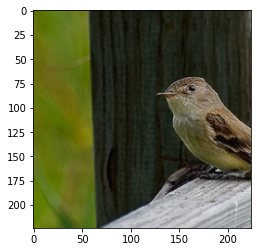

In [12]:
import matplotlib.pyplot as plt
import numpy as np


def unnorm(tensor):
    a = tensor.numpy()
    a = np.moveaxis(a, 0, -1)
    std = np.array([0.229, 0.224, 0.225])
    mean = np.array([0.485, 0.456, 0.406])
    return a * std + mean


plt.imshow(unnorm(inputs[0]))

In [3]:
outputs.softmax(dim=1) > 0.5

tensor([[False, False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False, False,
         False, False]], device='cuda:0')

In [4]:
col_names = [a for a in pd.read_csv("cub-labels.csv").columns if "_" in a]

In [5]:
for col, value in zip(col_names, outputs.softmax(dim=1)[0]):
    if value > 0.5:
        print(col, value)

In [6]:
for col, value in zip(col_names, labels[0]):
    if value:
        print(col, value)

has_bill_shape_all-purpose tensor(1)
has_wing_color_brown tensor(1)
has_wing_color_grey tensor(1)
has_wing_color_yellow tensor(1)
has_wing_color_black tensor(1)
has_wing_color_buff tensor(1)
has_upperparts_color_brown tensor(1)
has_upperparts_color_grey tensor(1)
has_upperparts_color_yellow tensor(1)
has_upperparts_color_black tensor(1)
has_underparts_color_grey tensor(1)
has_underparts_color_yellow tensor(1)
has_underparts_color_buff tensor(1)
has_breast_pattern_solid tensor(1)
has_back_color_grey tensor(1)
has_back_color_yellow tensor(1)
has_tail_shape_notched_tail tensor(1)
has_upper_tail_color_grey tensor(1)
has_breast_color_yellow tensor(1)
has_breast_color_buff tensor(1)
has_throat_color_yellow tensor(1)
has_throat_color_buff tensor(1)
has_eye_color_black tensor(1)
has_bill_length_about_the_same_as_head tensor(1)
has_bill_length_shorter_than_head tensor(1)
has_forehead_color_yellow tensor(1)
has_forehead_color_black tensor(1)
has_under_tail_color_grey tensor(1)
has_nape_color_gre

In [7]:
tmp = pd.read_csv("cub-labels.csv")
col_names = [a for a in pd.read_csv("cub-labels.csv").columns if "_" in a]
ratios = []

for col in col_names:
    count = tmp[col].values.sum()
    ratios.append(count / len(tmp))

In [8]:
ratios

[0.23201560909399388,
 0.09484221241940957,
 0.6761112996267391,
 0.4479131319986427,
 0.5334238208347472,
 0.6963013233797082,
 0.1865456396335256,
 0.8700373260943333,
 0.5419070240922973,
 0.34238208347472004,
 0.48286392941974887,
 0.6520190023752969,
 0.1865456396335256,
 0.8007295554801493,
 0.510858500169664,
 0.33746182558534105,
 0.19672548354258568,
 0.4334068544282321,
 0.19214455378350864,
 0.27366813708856463,
 0.6501526976586359,
 0.3722429589412962,
 0.8831862911435358,
 0.2023243976925687,
 0.40931455717678994,
 0.41253817441465895,
 0.5987444859178825,
 0.14675941635561587,
 0.5834747200542925,
 0.2800305395317272,
 0.3018323719036308,
 0.7542416016287751,
 0.3171021377672209,
 0.4827790973871734,
 0.5447064811672888,
 0.2006277570410587,
 0.2308279606379369,
 0.19443501866304716,
 0.5071258907363421,
 0.23150661689854088,
 0.40838140481845947,
 0.17687478791991856,
 0.37699355276552426,
 0.6401425178147269,
 0.37215812690872074,
 0.36019681031557516,
 0.13640990838140